**All the imports used**

In [852]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import joblib
from sklearn.preprocessing import StandardScaler


**Exploring the"train_data.csv"**

In [853]:
df = pd.read_csv('/content/Train data.csv')
display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [854]:
df = df.drop('Loan_ID', axis=1)
display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [855]:
# this function displays data types and non-null values
display(df.info())

#   iteration all over the data to show the unique values for each column
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Unique values in column '{col}': {df[col].unique()}")
    else:
        print(f"Column '{col}': Number of unique values = {df[col].nunique()}")

# Check for null values
print("\nNull values per column:")
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


None

Unique values in column 'Gender': ['Male' 'Female' nan]
Unique values in column 'Married': ['No' 'Yes' nan]
Unique values in column 'Dependents': ['0' '1' '2' '3+' nan]
Unique values in column 'Education': ['Graduate' 'Not Graduate']
Unique values in column 'Self_Employed': ['No' 'Yes' nan]
Column 'ApplicantIncome': Number of unique values = 505
Column 'CoapplicantIncome': Number of unique values = 287
Column 'LoanAmount': Number of unique values = 203
Column 'Loan_Amount_Term': Number of unique values = 10
Column 'Credit_History': Number of unique values = 2
Unique values in column 'Property_Area': ['Urban' 'Rural' 'Semiurban']
Unique values in column 'Loan_Status': ['Y' 'N']

Null values per column:


,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


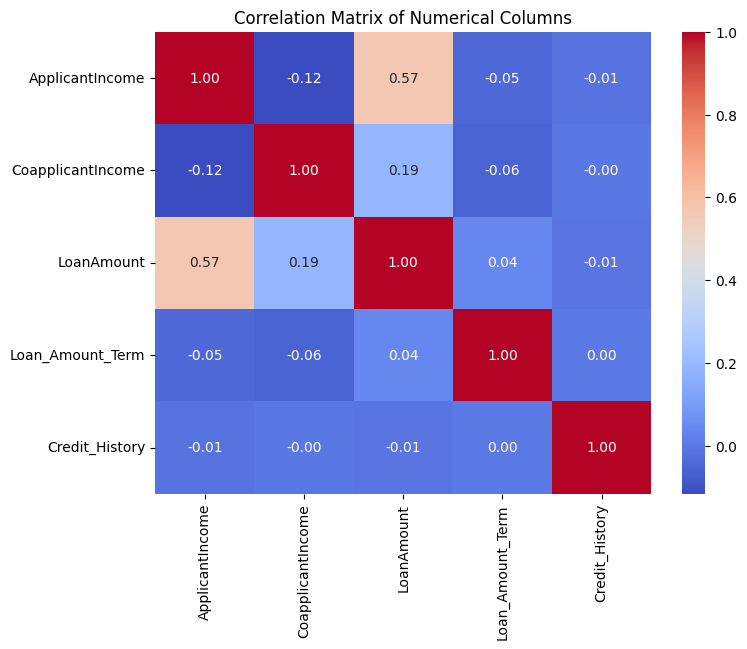

In [856]:
#selecting the numerical column to apply the correlation matrix
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

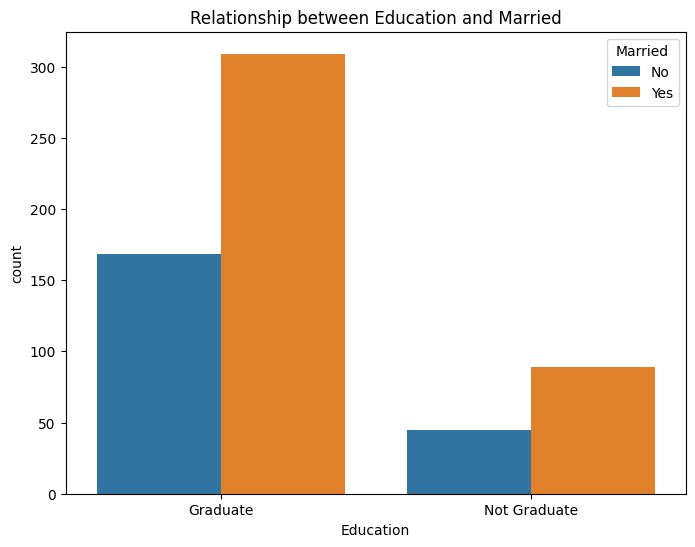

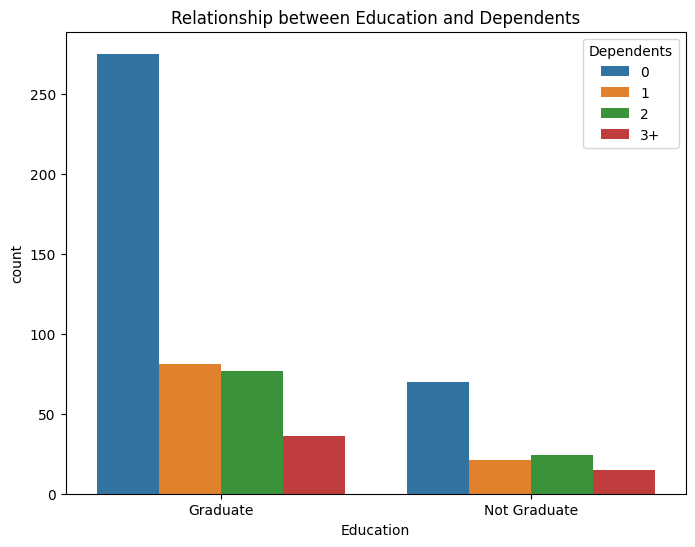

In [857]:
#seeing the relations between features
plt.figure(figsize=(8, 6))
sns.countplot(x='Education', hue='Married', data=df)
plt.title('Relationship between Education and Married')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='Education', hue='Dependents', data=df)
plt.title('Relationship between Education and Dependents')
plt.show()

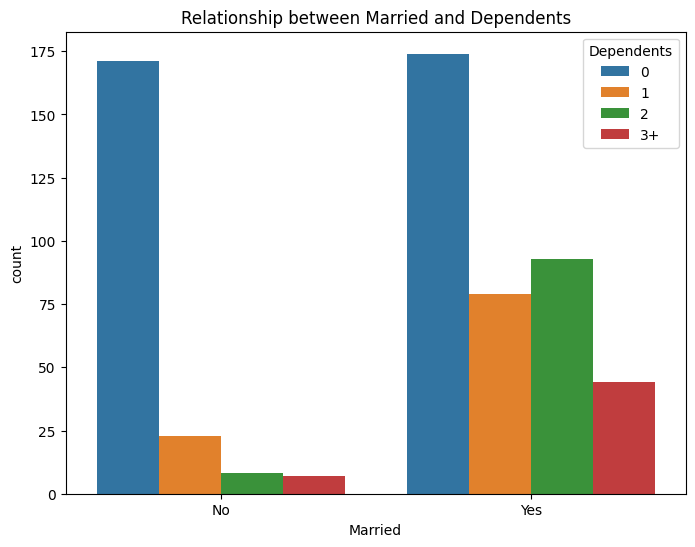

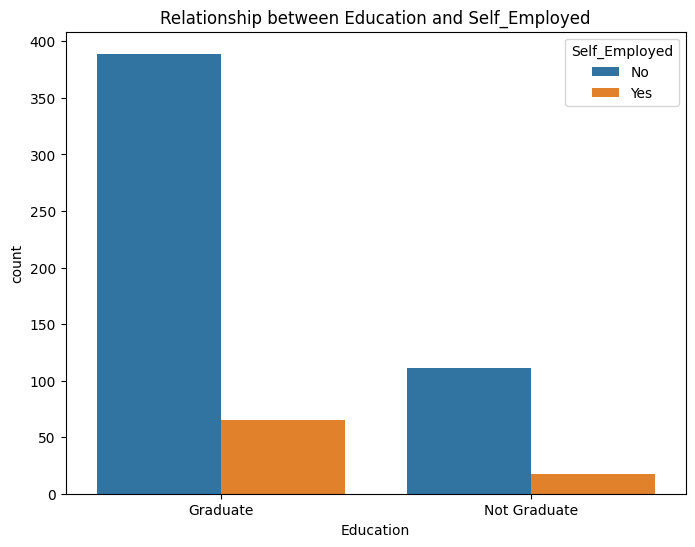

In [858]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Married', hue='Dependents', data=df)
plt.title('Relationship between Married and Dependents')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='Education', hue='Self_Employed', data=df)
plt.title('Relationship between Education and Self_Employed')
plt.show()

**Observations on Column Relationships:**

Based on the count plots and correlation matrix, we've observed the following relationships between the columns:

*   **Education and Married:** A higher proportion of Graduates appear to be married compared to Non-Graduates.
*   **Education and Dependents:** The distribution of dependents is somewhat similar between Graduates and Non-Graduates, with most individuals having 0 dependents in both groups.
*   **Married and Dependents:** Married individuals are more likely to have dependents (1, 2, or 3+) compared to those who are not married, where the majority have 0 dependents.
*   **Education and Self_Employed:** There isn't a very strong visual relationship between Education level and being Self-Employed based on the count plot. The proportions of Self-Employed individuals seem somewhat similar across both education levels.
*   **Numerical Columns (ApplicantIncome, CoapplicantIncome, LoanAmount):** The correlation matrix showed a moderate positive correlation (0.57) between 'ApplicantIncome' and 'LoanAmount'. 'CoapplicantIncome' has a weaker positive correlation with 'LoanAmount' (0.19) and a weak negative correlation with 'ApplicantIncome' (-0.12).

These observations can be helpful in understanding the data and guiding decisions for data preprocessing steps like imputation.

**Start cleaning the data**

In [859]:
# Impute missing values in 'Gender' with the mode
mode_gender = df['Gender'].mode()[0]
df['Gender'].fillna(mode_gender, inplace=True)

# Verify that null values in 'Gender' are filled
display(df.isnull().sum())

/tmp/ipython-input-1556606847.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(mode_gender, inplace=True)


,0
Gender,0
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [860]:
# Impute missing values in 'Married' based on 'Education'
# we assumed that when the applicant is graduate its more logic to be married than not graduate..
df.loc[df['Married'].isnull() & (df['Education'] == 'Graduate'), 'Married'] = 'Yes'
df.loc[df['Married'].isnull() & (df['Education'] == 'Not Graduate'), 'Married'] = 'No'

# Verify that null values in 'Married' are filled
display(df.isnull().sum())

,0
Gender,0
Married,0
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [861]:
# Impute missing values in 'Dependents' based on the mode within each 'Married' group
#we will impute the "dependent" column based on the mode of the married applicants that have dependents..
df['Dependents'] = df.groupby('Married')['Dependents'].transform(lambda x: x.fillna(x.mode()[0]))

# Verify that null values in 'Dependents' are filled
display(df.isnull().sum())

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [862]:
# Impute missing values in 'Self_Employed' with the mode
mode_self_employed = df['Self_Employed'].mode()[0]
df['Self_Employed'].fillna(mode_self_employed, inplace=True)

# Verify that null values in 'Self_Employed' are filled
display(df.isnull().sum())

/tmp/ipython-input-432232509.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Self_Employed'].fillna(mode_self_employed, inplace=True)


,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [863]:
# Impute missing values in 'Loan_Amount_Term' with the mode
mode_loan_amount_term = df['Loan_Amount_Term'].mode()[0]
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(mode_loan_amount_term)

# Verify that null values in 'Loan_Amount_Term' are filled
display(df.isnull().sum())

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,0
Credit_History,50


In [864]:
# Impute missing values in 'Credit_History' with the mode
mode_credit_history = df['Credit_History'].mode()[0]
df['Credit_History'] = df['Credit_History'].fillna(mode_credit_history)

# Verify that null values in 'Credit_History' are filled
display(df.isnull().sum())

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,0
Credit_History,0


**We will save the imputing startegies and the mode of each imputation that will be reused in the preprocessing of the "new_customer.csv" dataset**

In [865]:

# Save simple imputers / values
imputers = {
    "gender_mode": mode_gender,
    "self_employed_mode": mode_self_employed,
    "loan_term_mode": mode_loan_amount_term,
    "credit_history_mode": mode_credit_history,
}

joblib.dump(imputers, "simple_imputers.pkl")

# Save special rules
joblib.dump(df['Married'].mode()[0], "married_general_mode.pkl")

# Save groupwise dependents mode
dependents_mode_dict = df.groupby("Married")["Dependents"].agg(lambda x: x.mode()[0]).to_dict()
joblib.dump(dependents_mode_dict, "dependents_group_mode.pkl")


['dependents_group_mode.pkl']

**Now we will split the dataset int to DF's based on the "loan amount" column

In [866]:
df_missing_loanamount = df[df['LoanAmount'].isnull()]
df_not_missing_loanamount = df[df['LoanAmount'].notnull()]
display(df_missing_loanamount.head())
display(df_not_missing_loanamount.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
35,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y
63,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural,N
81,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban,Y
95,Male,No,0,Graduate,No,6782,0.0,NaN,360.0,1.0,Urban,N


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [867]:
#in the df that has no missing in loan amount we will select the numerical columns except the loan amount
numerical_cols = df_not_missing_loanamount.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in numerical_cols if col != 'LoanAmount']
#in the df we will select the categorical features
categorical_features = df_not_missing_loanamount.select_dtypes(include='object').columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']
Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


**By research we studied the features that will help predicting the loan amont**

In [868]:
# Based on the correlation matrix and domain knowledge, ApplicantIncome, CoapplicantIncome are likely good predictors.
# Loan_Amount_Term and Credit_History might also have some influence.
# For categorical features, Gender, Married, Dependents, Education, Self_Employed, and Property_Area could influence LoanAmount.
features = ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History',
            'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

print("Selected features for regression:", features)

Selected features for regression: ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [869]:
X_train = df_not_missing_loanamount[features]
y_train = df_not_missing_loanamount['LoanAmount']
#from the feature we select the categorical ones to encode them using one hot encoding
categorical_features_selected = X_train.select_dtypes(include='object').columns
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_features_selected])
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_features_selected), index=X_train.index)

X_train_final = pd.concat([X_train.drop(columns=categorical_features_selected), X_train_encoded_df], axis=1)

display(X_train_final.head())
display(y_train.head())

,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
1,4583,1508.0,360.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,3000,0.0,360.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,2583,2358.0,360.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,6000,0.0,360.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,5417,4196.0,360.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


,LoanAmount
1,128.0
2,66.0
3,120.0
4,141.0
5,267.0


**Building the regression model**

In [870]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train_final, y_train)

RandomForestRegressor(random_state=42)

**Predict missing values on the dataframe that has null values in the "loan amount" column**




In [871]:
# Select rows with missing 'LoanAmount'
df_predict_loanamount = df[df['LoanAmount'].isnull()].copy()
# Select the same features used for training
X_predict = df_predict_loanamount[features]
# Apply the same one-hot encoding transformation to categorical features
categorical_features_selected = X_predict.select_dtypes(include='object').columns
X_predict_encoded = one_hot_encoder.transform(X_predict[categorical_features_selected])
X_predict_encoded_df = pd.DataFrame(X_predict_encoded, columns=one_hot_encoder.get_feature_names_out(categorical_features_selected), index=X_predict.index)

# Concatenate numerical features and transformed categorical features
X_predict_final = pd.concat([X_predict.drop(columns=categorical_features_selected), X_predict_encoded_df], axis=1)
# Ensure the columns are in the same order as the training data
X_predict_final = X_predict_final[X_train_final.columns]
# Predict the 'LoanAmount' values
predicted_loanamount = model.predict(X_predict_final)
# Store the predicted 'LoanAmount' values
df_predict_loanamount['LoanAmount'] = predicted_loanamount
display(df_predict_loanamount.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,144.07,360.0,1.0,Urban,Y
35,Male,Yes,0,Graduate,No,2275,2067.0,99.13,360.0,1.0,Urban,Y
63,Male,Yes,1,Graduate,No,4945,0.0,110.53,360.0,0.0,Rural,N
81,Male,Yes,1,Graduate,Yes,2395,0.0,84.55,360.0,1.0,Semiurban,Y
95,Male,No,0,Graduate,No,6782,0.0,140.76,360.0,1.0,Urban,N


**Now we save the regression model to be used in the "new_customer.csv" dataset**

In [872]:
joblib.dump(model, "loanamount_regressor.pkl")
joblib.dump(one_hot_encoder, "loanamount_ohe.pkl")

['loanamount_ohe.pkl']

In [873]:
# Update the original DataFrame 'df' with the predicted 'LoanAmount' values
df.loc[df['LoanAmount'].isnull(), 'LoanAmount'] = df_predict_loanamount['LoanAmount']

# Verify that null values in 'LoanAmount' are filled
display(df.isnull().sum())

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [874]:
display(df.head())
display(df.isnull().sum())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,144.07,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.00,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.00,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.00,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.00,360.0,1.0,Urban,Y


,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [875]:
display(df)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,144.07,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.00,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.00,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.00,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.00,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.00,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.00,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.00,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.00,360.0,1.0,Urban,Y


In [876]:
df[(df["Married"]=="Yes") & (df["Property_Area"]=="Semiurban")].Loan_Status.value_counts()


,count
Loan_Status,
Y,123
N,30


**By research we find that we can make a new column with the same meaning of 2 columns which is "TotalIncome" that compensates the presence of "applicantIncome" and "CoapplicantIncome" columns**

**We tried to make some feature engineering and may that help in training the model later**

In [877]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df = df.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1)
display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0,Graduate,No,144.07,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.00,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,66.00,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,120.00,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,141.00,360.0,1.0,Urban,Y,6000.0


**Detecting the outliers**

In [878]:
#IQR_method
numerical_cols = ['LoanAmount', 'TotalIncome']
print("Outlier Detection using IQR:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"  Q1 (25th percentile): {Q1}")
    print(f"  Q3 (75th percentile): {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Lower Bound (Q1 - 1.5*IQR): {lower_bound}")
    print(f"  Upper Bound (Q3 + 1.5*IQR): {upper_bound}")
    print(f"  Number of outliers: {outliers.shape[0]}")
    if outliers.shape[0] > 0:
        display(outliers[[col]])

Outlier Detection using IQR:

Column: LoanAmount
  Q1 (25th percentile): 100.0
  Q3 (75th percentile): 166.9475
  IQR: 66.94749999999999
  Lower Bound (Q1 - 1.5*IQR): -0.42124999999998636
  Upper Bound (Q3 + 1.5*IQR): 267.36875
  Number of outliers: 40


,LoanAmount
9,349.00
21,315.00
34,320.00
54,286.00
67,312.00
126,370.00
130,650.00
135,290.00
155,600.00
161,275.00



Column: TotalIncome
  Q1 (25th percentile): 4166.0
  Q3 (75th percentile): 7521.75
  IQR: 3355.75
  Lower Bound (Q1 - 1.5*IQR): -867.625
  Upper Bound (Q3 + 1.5*IQR): 12555.375
  Number of outliers: 50


,TotalIncome
9,23809.0
34,15500.0
102,13650.0
115,14583.0
126,23803.0
128,14363.0
130,20166.0
138,14999.0
146,14866.0
155,39999.0


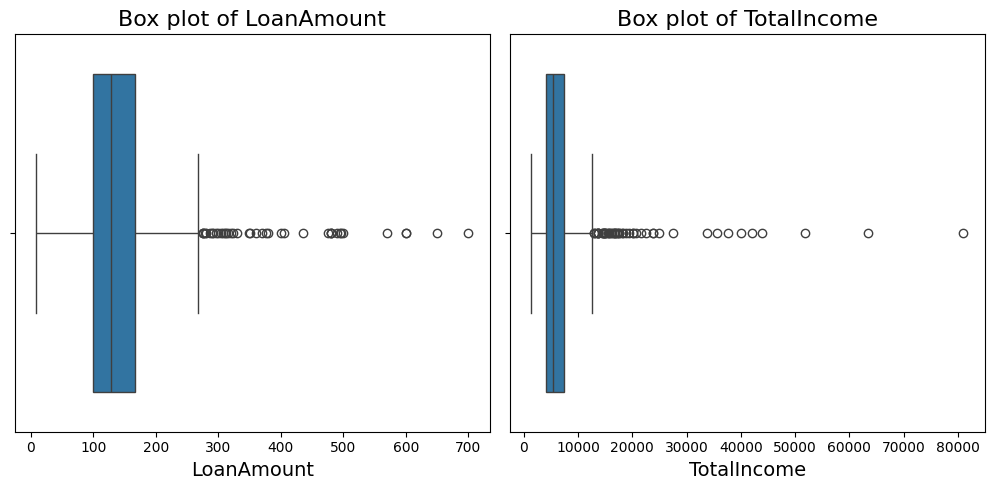

In [879]:
#BoxPlot_method
numerical_cols = ['LoanAmount', 'TotalIncome']
plt.figure(figsize=(15, 5)) # Adjusted figure size
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1) # Adjusted subplot grid for 1 row and 3 columns
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}', fontsize=16)
    plt.xlabel(col, fontsize=14)
plt.tight_layout()
plt.show()

**IMPORTANT NOTE:
Not all outliers are “bad values.” Some represent real, important cases. Removing them might throw away meaningful information that the model must learn.
So,from our observations we decided not remove them because removing them will lead to data leakage as these outliers occur because of real-world conditions, not because of errors.**

**loan approval problem is inherently risk-based, so values that appear “extreme" might be exactly what the model needs!**

**The best solution was to transform the data using "LogTransformnation"**

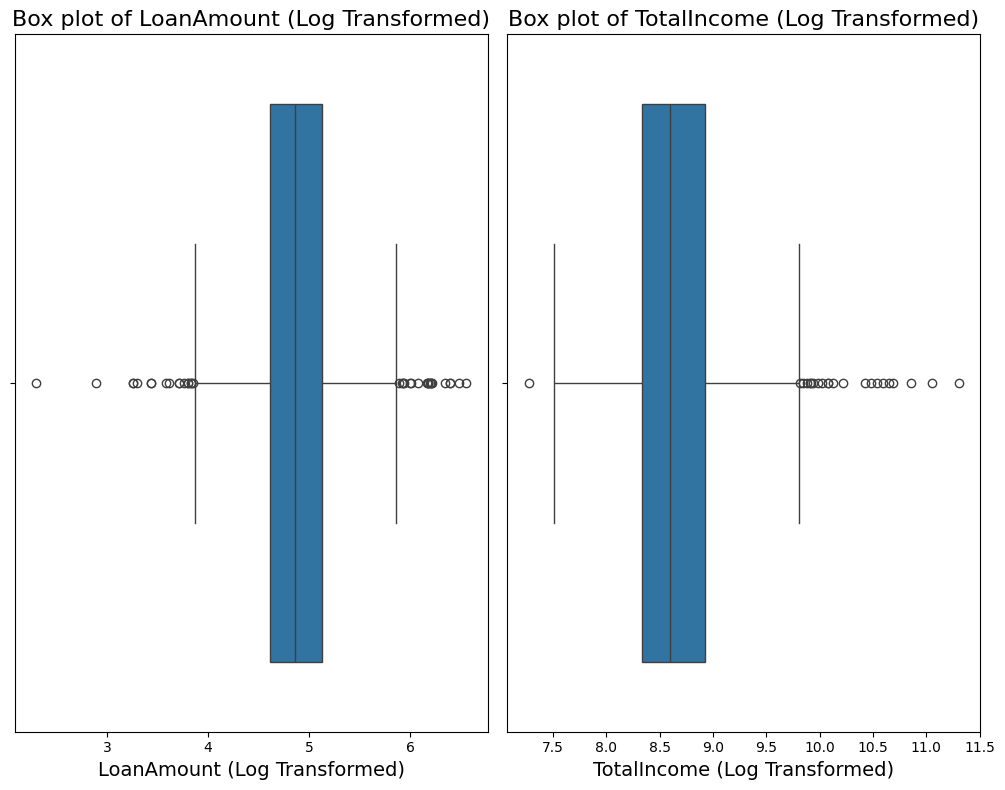

In [880]:
df['LoanAmount_log'] = np.log(df['LoanAmount'] + 1)
df['TotalIncome_log'] = np.log(df['TotalIncome'] + 1)

# Visualize the distributions after log transformation
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['LoanAmount_log'])
plt.title('Box plot of LoanAmount (Log Transformed)', fontsize=16)
plt.xlabel('LoanAmount (Log Transformed)', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['TotalIncome_log'])
plt.title('Box plot of TotalIncome (Log Transformed)', fontsize=16)
plt.xlabel('TotalIncome (Log Transformed)', fontsize=14)

plt.tight_layout()
plt.show()

In [881]:
numerical_cols_processed = ['LoanAmount_log', 'TotalIncome_log']

print("Outlier Detection using IQR (Transformed and/or Capped Data):")
for col in numerical_cols_processed:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"  Q1 (25th percentile): {Q1}")
    print(f"  Q3 (75th percentile): {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Lower Bound (Q1 - 1.5*IQR): {lower_bound}")
    print(f"  Upper Bound (Q3 + 1.5*IQR): {upper_bound}")
    print(f"  Number of outliers: {outliers.shape[0]}")
    if outliers.shape[0] > 0:
        display(outliers[[col]])

Outlier Detection using IQR (Transformed and/or Capped Data):

Column: LoanAmount_log
  Q1 (25th percentile): 4.61512051684126
  Q3 (75th percentile): 5.123651283927845
  IQR: 0.5085307670865857
  Lower Bound (Q1 - 1.5*IQR): 3.852324366211381
  Upper Bound (Q3 + 1.5*IQR): 5.886447434557724
  Number of outliers: 37


,LoanAmount_log
14,2.890372
28,3.583519
46,3.806662
94,3.258097
121,3.806662
126,5.916202
130,6.478510
133,3.258097
147,3.433987
155,6.398595



Column: TotalIncome_log
  Q1 (25th percentile): 8.334951631422454
  Q3 (75th percentile): 8.925682377212238
  IQR: 0.5907307457897844
  Lower Bound (Q1 - 1.5*IQR): 7.448855512737778
  Upper Bound (Q3 + 1.5*IQR): 9.811778495896915
  Number of outliers: 22


,TotalIncome_log
9,10.077861
28,7.274480
126,10.077609
130,9.911803
155,10.596635
171,10.854450
183,10.429606
185,10.689624
284,9.936342
308,9.915120


**Additionally,we applied "gentle capping"**

**Gentle capping means setting extreme outliers to a maximum acceptable value so they don’t distort model training, while still keeping all rows in the dataset.**

In [882]:
cols_to_cap = ['LoanAmount_log', 'TotalIncome_log']
caps = {}

print("Capping values at the 99.5th percentile:")

for col in cols_to_cap:
    cap_value = df[col].quantile(0.995)     # in *raw log space*
    df[col] = np.clip(df[col], a_min=None, a_max=cap_value)
    caps[col] = cap_value
    print(f"  Column '{col}': Cap value used = {cap_value:.4f}")

# Save caps to reuse in new_customer preprocessing
joblib.dump(caps, "log_caps.pkl")
print("Saved log capping thresholds to 'log_caps.pkl'")


Capping values at the 99.5th percentile:
  Column 'LoanAmount_log': Cap value used = 6.3953
  Column 'TotalIncome_log': Cap value used = 10.6869
Saved log capping thresholds to 'log_caps.pkl'


**Summary of handling the outliers:**

 Log transform:

1)reduces the spread

2)makes skewed distributions more normal

3)reduces impact of large values
,But there can still be a few peaks.

**Capping them prevents the model from getting biased by them.**

*Log + gentle cap = optimal outlier handling for numeric features.*

**encoding the categorical features**

In [883]:
# Assuming 'Dependents' and 'Education' are ordinal based on prior steps
# Other object type columns are considered nominal
ordinal_cols = ['Dependents', 'Education']
nominal_cols = [col for col in df.select_dtypes(include='object').columns if col not in ordinal_cols + ['Loan_Status']]

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)
# Perform Label Encoding for ordinal columns
for col in ordinal_cols:
    if col in df.columns and df[col].dtype == 'object':
        if col == 'Dependents':
             df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)
        elif col == 'Education':
             df['Education'] = df['Education'].map({'Not Graduate': 0, 'Graduate': 1})
# Perform One-Hot Encoding for nominal columns
nominal_cols_to_encode = [col for col in nominal_cols if col in df.columns and df[col].dtype == 'object']
if nominal_cols_to_encode:
    df = pd.get_dummies(df, columns=nominal_cols_to_encode, drop_first=True) # drop_first=True to avoid multicollinearity
# Encode the target variable 'Loan_Status'
if 'Loan_Status' in df.columns and df['Loan_Status'].dtype == 'object':
     label_encoder = LabelEncoder()
     df['Loan_Status'] = label_encoder.fit_transform(df['Loan_Status'])
display(df.head())
display(df.dtypes)

Ordinal columns: ['Dependents', 'Education']
Nominal columns: ['Gender', 'Married', 'Self_Employed', 'Property_Area']


,Dependents,Education,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,1,144.07,360.0,1.0,1,5849.0,4.977216,8.674197,True,False,False,False,True
1,1,1,128.00,360.0,1.0,0,6091.0,4.859812,8.714732,True,True,False,False,False
2,0,1,66.00,360.0,1.0,1,3000.0,4.204693,8.006701,True,True,True,False,True
3,0,0,120.00,360.0,1.0,1,4941.0,4.795791,8.505525,True,True,False,False,True
4,0,1,141.00,360.0,1.0,1,6000.0,4.955827,8.699681,True,False,False,False,True


,0
Dependents,int64
Education,int64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Loan_Status,int64
TotalIncome,float64
LoanAmount_log,float64
TotalIncome_log,float64
Gender_Male,bool


In [884]:
display(df.head())
display(df.isnull().sum())

,Dependents,Education,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,1,144.07,360.0,1.0,1,5849.0,4.977216,8.674197,True,False,False,False,True
1,1,1,128.00,360.0,1.0,0,6091.0,4.859812,8.714732,True,True,False,False,False
2,0,1,66.00,360.0,1.0,1,3000.0,4.204693,8.006701,True,True,True,False,True
3,0,0,120.00,360.0,1.0,1,4941.0,4.795791,8.505525,True,True,False,False,True
4,0,1,141.00,360.0,1.0,1,6000.0,4.955827,8.699681,True,False,False,False,True


,0
Dependents,0
Education,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Loan_Status,0
TotalIncome,0
LoanAmount_log,0
TotalIncome_log,0
Gender_Male,0


**scaling the numerical columns**

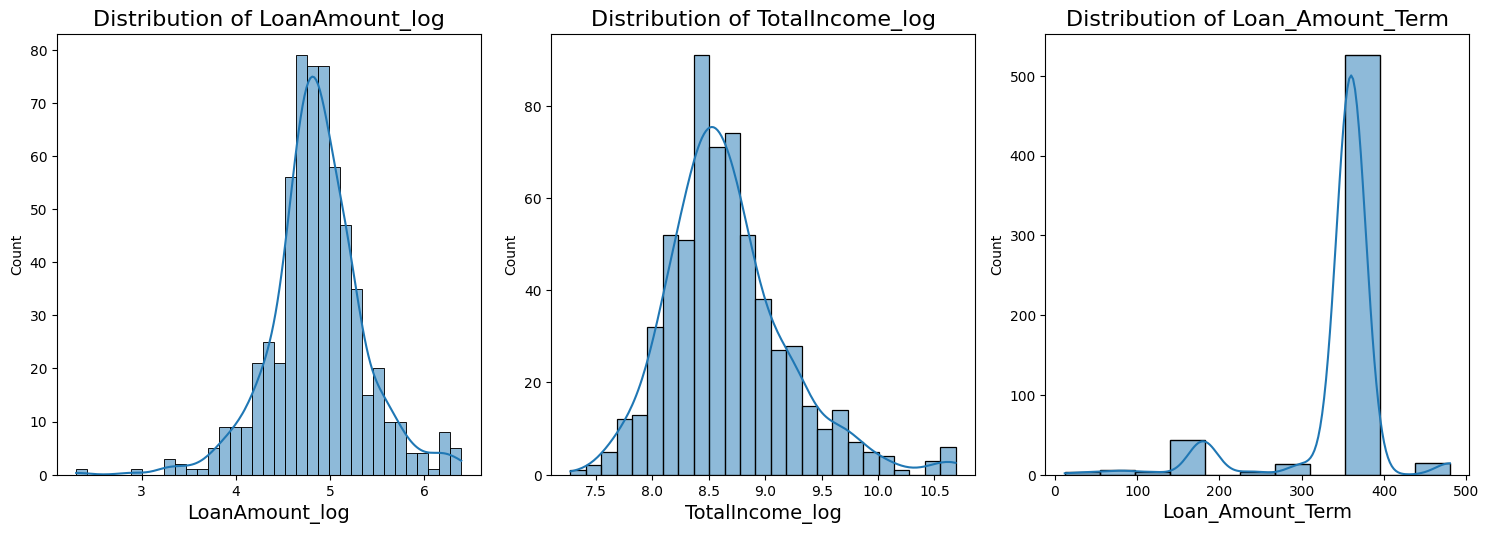

In [885]:
numerical_cols_to_scale = ['LoanAmount_log', 'TotalIncome_log', 'Loan_Amount_Term']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_to_scale):
    plt.subplot(2, 3, i + 1) # Adjusted subplot grid for 2 rows and 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(col, fontsize=14)
plt.tight_layout()
plt.show()

In [886]:
numerical_cols_to_scale = ['LoanAmount_log', 'TotalIncome_log', 'Loan_Amount_Term']
scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

display(df.head())

,Dependents,Education,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,1,144.07,0.273231,1.0,1,5849.0,0.222345,0.012054,True,False,False,False,True
1,1,1,128.00,0.273231,1.0,0,6091.0,-0.014152,0.087575,True,True,False,False,False
2,0,1,66.00,0.273231,1.0,1,3000.0,-1.333819,-1.231575,True,True,True,False,True
3,0,0,120.00,0.273231,1.0,1,4941.0,-0.143117,-0.302203,True,True,False,False,True
4,0,1,141.00,0.273231,1.0,1,6000.0,0.179259,0.059534,True,False,False,False,True


**saving the scaler**

In [887]:
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [888]:
drop_columns = ['LoanAmount', 'TotalIncome']
df = df.drop(drop_columns, axis=1)
display(df.head())

,Dependents,Education,Loan_Amount_Term,Credit_History,Loan_Status,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,1,0.273231,1.0,1,0.222345,0.012054,True,False,False,False,True
1,1,1,0.273231,1.0,0,-0.014152,0.087575,True,True,False,False,False
2,0,1,0.273231,1.0,1,-1.333819,-1.231575,True,True,True,False,True
3,0,0,0.273231,1.0,1,-0.143117,-0.302203,True,True,False,False,True
4,0,1,0.273231,1.0,1,0.179259,0.059534,True,False,False,False,True


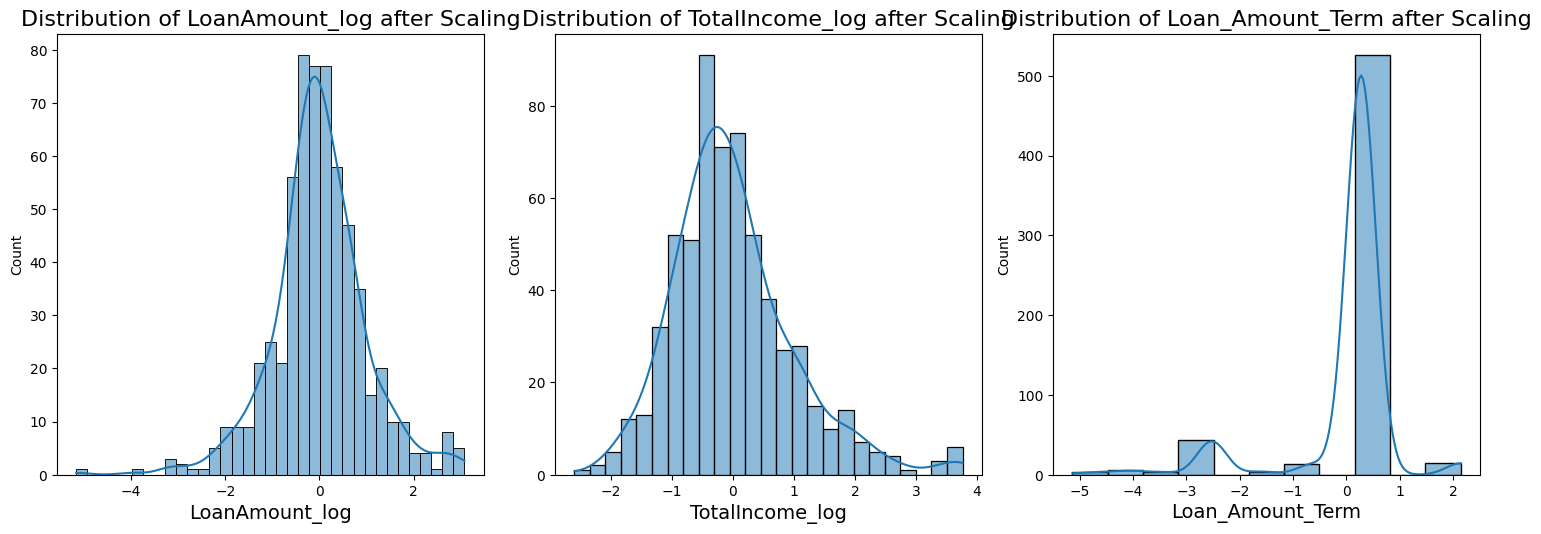

In [889]:
numerical_cols_after_scaling = ['LoanAmount_log', 'TotalIncome_log', 'Loan_Amount_Term']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_after_scaling):
    plt.subplot(2, 3, i + 1) # Adjusted subplot grid for 2 rows and 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} after Scaling', fontsize=16)
    plt.xlabel(col, fontsize=14)
plt.tight_layout()
plt.show()

In [890]:
df.to_csv('preprocessed_data.csv', index=False)
print("Preprocessed data saved to 'preprocessed_data.csv'")

Preprocessed data saved to 'preprocessed_data.csv'


**building models**

**Imports used for models**

In [891]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler, Binarizer


**a. XGBOOST**

In [892]:
# Check class distribution
print("=" * 60)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 60)
print("\nOriginal class distribution:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

CLASS DISTRIBUTION ANALYSIS

Original class distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64

Class proportions:
Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64


In [893]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = XGBClassifier(
max_depth=3,
learning_rate=0.02,
n_estimators=2000,
subsample=0.7,
colsample_bytree=0.7,
min_child_weight=1,
gamma=0.1,
reg_alpha=3,
reg_lambda=3,
early_stopping_rounds=50
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.8536585365853658
[[21 17]
 [ 1 84]]
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [894]:

print("STRATEGY 1: SMOTE - Synthetic Minority Oversampling")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - class distribution:")
print(pd.Series(y_train_smote).value_counts())

# XGBoost with SMOTE
xgb_smote = XGBClassifier(
    max_depth=3,
    learning_rate=0.02,
    n_estimators=2000,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0.1,
    reg_alpha=3,
    reg_lambda=3,
    early_stopping_rounds=50,
    random_state=42
)
xgb_smote.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_smote = xgb_smote.predict(X_test)

print("\nXGBoost with SMOTE Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_smote):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


STRATEGY 1: SMOTE - Synthetic Minority Oversampling

After SMOTE - class distribution:
Loan_Status
1    337
0    337
Name: count, dtype: int64

XGBoost with SMOTE Results:
Accuracy: 0.7886
ROC-AUC: 0.7307

Confusion Matrix:
[[22 16]
 [10 75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.58      0.63        38
           1       0.82      0.88      0.85        85

    accuracy                           0.79       123
   macro avg       0.76      0.73      0.74       123
weighted avg       0.78      0.79      0.78       123



In [895]:
print("STRATEGY 2: Using Class Weights")


# Calculate class weights
class_weights = {0: len(y_train) / (2 * (y_train == 0).sum()),
                 1: len(y_train) / (2 * (y_train == 1).sum())}
print(f"\nCalculated class weights: {class_weights}")

# XGBoost with class weights
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = XGBClassifier(
    max_depth=3,
    learning_rate=0.02,
    n_estimators=2000,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0.1,
    reg_alpha=3,
    reg_lambda=3,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    random_state=42
)
xgb_weighted.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_weighted = xgb_weighted.predict(X_test)

print("\nXGBoost with Class Weights Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_weighted):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))


STRATEGY 2: Using Class Weights

Calculated class weights: {0: np.float64(1.594155844155844), 1: np.float64(0.728486646884273)}

XGBoost with Class Weights Results:
Accuracy: 0.7724
ROC-AUC: 0.7262

Confusion Matrix:
[[23 15]
 [13 72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.61      0.62        38
           1       0.83      0.85      0.84        85

    accuracy                           0.77       123
   macro avg       0.73      0.73      0.73       123
weighted avg       0.77      0.77      0.77       123



In [896]:
joblib.dump(list(X_train.columns), "training_columns.pkl")
print("Training column order saved!")
X_train.columns

Training column order saved!


Index(['Dependents', 'Education', 'Loan_Amount_Term', 'Credit_History',
       'LoanAmount_log', 'TotalIncome_log', 'Gender_Male', 'Married_Yes',
       'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [897]:
print("STRATEGY 3: Threshold Tuning")


# Get probability predictions
y_pred_proba = xgb_smote.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.3, 0.7, 0.05)
best_threshold = 0.5
best_recall_0 = 0

print("\nTesting different thresholds:")
for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    recall_0 = report['0']['recall']
    recall_1 = report['1']['recall']
    print(f"Threshold: {threshold:.2f} | Recall Class 0: {recall_0:.4f} | Recall Class 1: {recall_1:.4f}")

    if recall_0 > best_recall_0:
        best_recall_0 = recall_0
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold:.2f}")
y_pred_best_thresh = (y_pred_proba >= best_threshold).astype(int)

print("\nXGBoost with Optimized Threshold Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_thresh):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_best_thresh):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_thresh))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_thresh))


STRATEGY 3: Threshold Tuning

Testing different thresholds:
Threshold: 0.30 | Recall Class 0: 0.5526 | Recall Class 1: 0.9882
Threshold: 0.35 | Recall Class 0: 0.5526 | Recall Class 1: 0.9882
Threshold: 0.40 | Recall Class 0: 0.5526 | Recall Class 1: 0.9882
Threshold: 0.45 | Recall Class 0: 0.5526 | Recall Class 1: 0.9647
Threshold: 0.50 | Recall Class 0: 0.5789 | Recall Class 1: 0.8824
Threshold: 0.55 | Recall Class 0: 0.5789 | Recall Class 1: 0.8471
Threshold: 0.60 | Recall Class 0: 0.7105 | Recall Class 1: 0.7412
Threshold: 0.65 | Recall Class 0: 0.7632 | Recall Class 1: 0.6353

Best threshold: 0.65

XGBoost with Optimized Threshold Results:
Accuracy: 0.6748
ROC-AUC: 0.6992

Confusion Matrix:
[[29  9]
 [31 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.76      0.59        38
           1       0.86      0.64      0.73        85

    accuracy                           0.67       123
   macro avg       0.67      0.70 

In [898]:

print("STRATEGY 4: ADASYN - Adaptive Synthetic Sampling")


adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("\nAfter ADASYN - class distribution:")
print(pd.Series(y_train_adasyn).value_counts())

# XGBoost with ADASYN
xgb_adasyn = XGBClassifier(
    max_depth=3,
    learning_rate=0.02,
    n_estimators=2000,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0.1,
    reg_alpha=3,
    reg_lambda=3,
    early_stopping_rounds=50,
    random_state=42
)
xgb_adasyn.fit(
    X_train_adasyn, y_train_adasyn,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_adasyn = xgb_adasyn.predict(X_test)

print("\nXGBoost with ADASYN Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adasyn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_adasyn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_adasyn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_adasyn))

STRATEGY 4: ADASYN - Adaptive Synthetic Sampling

After ADASYN - class distribution:
Loan_Status
1    337
0    323
Name: count, dtype: int64

XGBoost with ADASYN Results:
Accuracy: 0.8049
ROC-AUC: 0.7351

Confusion Matrix:
[[21 17]
 [ 7 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.55      0.64        38
           1       0.82      0.92      0.87        85

    accuracy                           0.80       123
   macro avg       0.79      0.74      0.75       123
weighted avg       0.80      0.80      0.80       123



In [899]:

print("STRATEGY 5: SMOTE + Tomek Links (Hybrid Approach)")


smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

print("\nAfter SMOTE-Tomek - class distribution:")
print(pd.Series(y_train_st).value_counts())

# XGBoost with SMOTE-Tomek
xgb_st = XGBClassifier(
    max_depth=3,
    learning_rate=0.02,
    n_estimators=2000,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0.1,
    reg_alpha=3,
    reg_lambda=3,
    early_stopping_rounds=50,
    random_state=42
)
xgb_st.fit(
    X_train_st, y_train_st,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_st = xgb_st.predict(X_test)

print("\nXGBoost with SMOTE-Tomek Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_st):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_st):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_st))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_st))

STRATEGY 5: SMOTE + Tomek Links (Hybrid Approach)

After SMOTE-Tomek - class distribution:
Loan_Status
1    319
0    319
Name: count, dtype: int64

XGBoost with SMOTE-Tomek Results:
Accuracy: 0.7805
ROC-AUC: 0.7320

Confusion Matrix:
[[23 15]
 [12 73]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.61      0.63        38
           1       0.83      0.86      0.84        85

    accuracy                           0.78       123
   macro avg       0.74      0.73      0.74       123
weighted avg       0.78      0.78      0.78       123



**B.Decision tree**

In [900]:


X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
print("Feature columns:", list(X.columns))
print("Target sample values:", y.unique())

Feature columns: ['Dependents', 'Education', 'Loan_Amount_Term', 'Credit_History', 'LoanAmount_log', 'TotalIncome_log', 'Gender_Male', 'Married_Yes', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
Target sample values: [1 0]


In [901]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    stratify=y          # keeps same 0/1 ratio in train and test
)

In [902]:
dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,          # prevents overfitting
    min_samples_split=10, # no splits for tiny groups
    min_samples_leaf=5,   # ensures smooth leaves
    random_state=42
)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy on test set: 0.8536585365853658
[[23 15]
 [ 3 82]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.61      0.72        38
           1       0.85      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



In [903]:

print("STRATEGY 6: Decision Tree with Class Weights")
dt_weighted = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # Automatically adjusts weights
    random_state=42
)
dt_weighted.fit(X_train, y_train)
y_pred_dt_weighted = dt_weighted.predict(X_test)

print("\nDecision Tree with Balanced Weights Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_weighted):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_dt_weighted):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_weighted))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_weighted))



STRATEGY 6: Decision Tree with Class Weights

Decision Tree with Balanced Weights Results:
Accuracy: 0.8211
ROC-AUC: 0.7687

Confusion Matrix:
[[24 14]
 [ 8 77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123



**C. KNN**

In [904]:

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Plot Accuracy vs K**

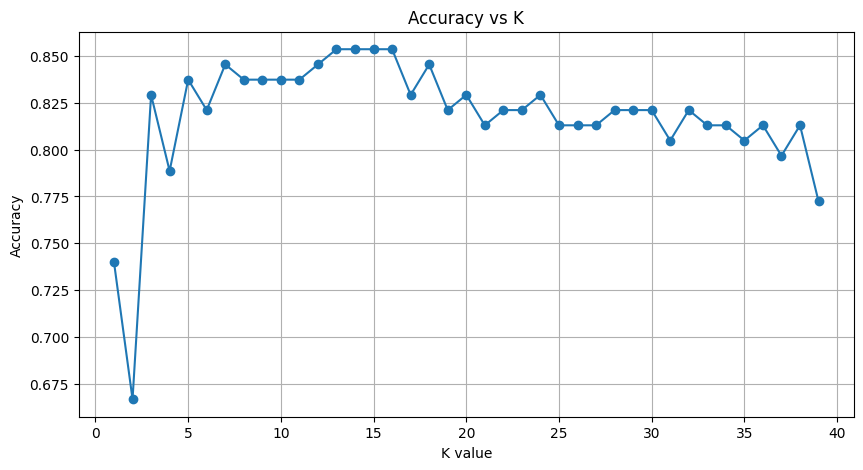

In [905]:
accuracies = []
k_values = range(1, 40)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K')
plt.grid()
plt.show()

**Find the best K using Grid Search**

In [906]:

param_grid = {
    'n_neighbors': list(range(1, 40)),
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best K parameters:", grid.best_params_)
best_k = grid.best_params_['n_neighbors']
best_metric = grid.best_params_['metric']

Best K parameters: {'metric': 'euclidean', 'n_neighbors': 18}


In [907]:
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Test Accuracy: 0.8455284552845529
[[20 18]
 [ 1 84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.53      0.68        38
           1       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



In [908]:

print("STRATEGY 1: KNN with SMOTE")


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE - class distribution:")
print(pd.Series(y_train_smote).value_counts())

# Find best K for SMOTE data
param_grid_smote = {
    'n_neighbors': list(range(3, 30, 2)),
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_smote = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_smote,
    cv=5,
    scoring='recall_macro',  # Focuses on balanced recall
    n_jobs=-1
)
grid_smote.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters: {grid_smote.best_params_}")

knn_smote = grid_smote.best_estimator_
y_pred_smote = knn_smote.predict(X_test_scaled)

print("\nKNN with SMOTE Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_smote):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


STRATEGY 1: KNN with SMOTE

After SMOTE - class distribution:
Loan_Status
1    337
0    337
Name: count, dtype: int64

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3}

KNN with SMOTE Results:
Accuracy: 0.7480
ROC-AUC: 0.7303

Confusion Matrix:
[[26 12]
 [19 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.68      0.63        38
           1       0.85      0.78      0.81        85

    accuracy                           0.75       123
   macro avg       0.71      0.73      0.72       123
weighted avg       0.76      0.75      0.75       123



In [909]:

print("STRATEGY 2: KNN with Distance and Class Weights")


# KNN with distance weighting (closer neighbors have more influence)
knn_weighted = KNeighborsClassifier(
    n_neighbors=15,
    metric='manhattan',
    weights='distance'  # Weight by inverse distance
)
knn_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = knn_weighted.predict(X_test_scaled)

print("\nKNN with Distance Weighting Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_weighted):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))


STRATEGY 2: KNN with Distance and Class Weights

KNN with Distance Weighting Results:
Accuracy: 0.8374
ROC-AUC: 0.7587

Confusion Matrix:
[[21 17]
 [ 3 82]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.55      0.68        38
           1       0.83      0.96      0.89        85

    accuracy                           0.84       123
   macro avg       0.85      0.76      0.78       123
weighted avg       0.84      0.84      0.83       123



In [910]:

print("STRATEGY 3: KNN with ADASYN")


adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

print("\nAfter ADASYN - class distribution:")
print(pd.Series(y_train_adasyn).value_counts())

# Find best K for ADASYN data
grid_adasyn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_smote,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)
grid_adasyn.fit(X_train_adasyn, y_train_adasyn)

print(f"\nBest parameters: {grid_adasyn.best_params_}")

knn_adasyn = grid_adasyn.best_estimator_
y_pred_adasyn = knn_adasyn.predict(X_test_scaled)

print("\nKNN with ADASYN Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adasyn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_adasyn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_adasyn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_adasyn))

STRATEGY 3: KNN with ADASYN

After ADASYN - class distribution:
Loan_Status
1    337
0    324
Name: count, dtype: int64

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3}

KNN with ADASYN Results:
Accuracy: 0.7236
ROC-AUC: 0.7200

Confusion Matrix:
[[27 11]
 [23 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.71      0.61        38
           1       0.85      0.73      0.78        85

    accuracy                           0.72       123
   macro avg       0.69      0.72      0.70       123
weighted avg       0.75      0.72      0.73       123



In [911]:

print("STRATEGY 4: KNN with SMOTE-Tomek")

smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE-Tomek - class distribution:")
print(pd.Series(y_train_st).value_counts())

# Find best K for SMOTE-Tomek data
grid_st = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_smote,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)
grid_st.fit(X_train_st, y_train_st)

print(f"\nBest parameters: {grid_st.best_params_}")

knn_st = grid_st.best_estimator_
y_pred_st = knn_st.predict(X_test_scaled)

print("\nKNN with SMOTE-Tomek Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_st):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_st):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_st))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_st))



STRATEGY 4: KNN with SMOTE-Tomek

After SMOTE-Tomek - class distribution:
Loan_Status
1    317
0    317
Name: count, dtype: int64

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3}

KNN with SMOTE-Tomek Results:
Accuracy: 0.7480
ROC-AUC: 0.7303

Confusion Matrix:
[[26 12]
 [19 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.68      0.63        38
           1       0.85      0.78      0.81        85

    accuracy                           0.75       123
   macro avg       0.71      0.73      0.72       123
weighted avg       0.76      0.75      0.75       123



In [912]:

print("STRATEGY 5: KNN with Threshold Tuning")


# Use the SMOTE model for probability predictions
y_pred_proba = knn_smote.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
thresholds = np.arange(0.25, 0.75, 0.05)
best_threshold = 0.5
best_recall_0 = 0
results = []

print("\nTesting different thresholds:")
for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    recall_0 = report['0']['recall']
    recall_1 = report['1']['recall']
    acc = accuracy_score(y_test, y_pred_thresh)

    results.append({
        'threshold': threshold,
        'recall_0': recall_0,
        'recall_1': recall_1,
        'accuracy': acc,
        'balanced_recall': (recall_0 + recall_1) / 2
    })

    print(f"Threshold: {threshold:.2f} | Recall 0: {recall_0:.4f} | Recall 1: {recall_1:.4f} | Acc: {acc:.4f}")

    if recall_0 > best_recall_0:
        best_recall_0 = recall_0
        best_threshold = threshold

print(f"\nBest threshold for Class 0 recall: {best_threshold:.2f}")
y_pred_best_thresh = (y_pred_proba >= best_threshold).astype(int)

print("\nKNN with Optimized Threshold Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_thresh):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_best_thresh):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_thresh))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_thresh))

STRATEGY 5: KNN with Threshold Tuning

Testing different thresholds:
Threshold: 0.25 | Recall 0: 0.5263 | Recall 1: 0.9412 | Acc: 0.8130
Threshold: 0.30 | Recall 0: 0.5263 | Recall 1: 0.9412 | Acc: 0.8130
Threshold: 0.35 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.40 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.45 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.50 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.55 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.60 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.65 | Recall 0: 0.6842 | Recall 1: 0.7765 | Acc: 0.7480
Threshold: 0.70 | Recall 0: 0.7368 | Recall 1: 0.5294 | Acc: 0.5935

Best threshold for Class 0 recall: 0.70

KNN with Optimized Threshold Results:
Accuracy: 0.5935
ROC-AUC: 0.6331

Confusion Matrix:
[[28 10]
 [40 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.

In [913]:

print("STRATEGY 6: KNN with Smaller K + SMOTE")


# Try smaller K values which can help minority class
param_grid_small_k = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

grid_small_k = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_small_k,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)
grid_small_k.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters: {grid_small_k.best_params_}")

knn_small_k = grid_small_k.best_estimator_
y_pred_small_k = knn_small_k.predict(X_test_scaled)

print("\nKNN with Smaller K + SMOTE Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_small_k):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_small_k):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_small_k))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_small_k))

STRATEGY 6: KNN with Smaller K + SMOTE

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

KNN with Smaller K + SMOTE Results:
Accuracy: 0.7480
ROC-AUC: 0.7303

Confusion Matrix:
[[26 12]
 [19 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.68      0.63        38
           1       0.85      0.78      0.81        85

    accuracy                           0.75       123
   macro avg       0.71      0.73      0.72       123
weighted avg       0.76      0.75      0.75       123



**naive bayes**

In [914]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Train/Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [915]:
results_baseline = {}
gnb = GaussianNB()
gnb.fit(X_train, y_train)
pred_gnb = gnb.predict(X_test)

results_baseline["GaussianNB"] = accuracy_score(y_test, pred_gnb)

print("Gaussian NB")
print(classification_report(y_test, pred_gnb))


Gaussian NB
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [916]:
scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)
mnb = MultinomialNB()
mnb.fit(X_train_mm, y_train)
pred_mnb = mnb.predict(X_test_mm)

results_baseline["MultinomialNB"] = accuracy_score(y_test, pred_mnb)

print(" Multinomial NB ")
print(classification_report(y_test, pred_mnb))


 Multinomial NB 
              precision    recall  f1-score   support

           0       1.00      0.03      0.05        38
           1       0.70      1.00      0.82        85

    accuracy                           0.70       123
   macro avg       0.85      0.51      0.44       123
weighted avg       0.79      0.70      0.58       123



In [917]:
binarizer = Binarizer(threshold=X_train.mean().mean())
X_train_bin = binarizer.fit_transform(X_train)
X_test_bin = binarizer.transform(X_test)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
pred_bnb = bnb.predict(X_test_bin)

results_baseline["BernoulliNB"] = accuracy_score(y_test, pred_bnb)

print("Bernoulli NB ")
print(classification_report(y_test, pred_bnb))


print("\nBaseline model accuracies:\n", results_baseline)

Bernoulli NB 
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123


Baseline model accuracies:
 {'GaussianNB': 0.8536585365853658, 'MultinomialNB': 0.6991869918699187, 'BernoulliNB': 0.8536585365853658}


In [918]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

gnb_sm = GaussianNB()
gnb_sm.fit(X_train_sm, y_train_sm)
pred_gnb_sm = gnb_sm.predict(X_test)

print("Gaussian NB + SMOTE ")
print(classification_report(y_test, pred_gnb_sm))


Gaussian NB + SMOTE 
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [919]:

# Compute class weights manually
class_counts = y_train.value_counts()
total = len(y_train)

weights = np.where(y_train == 1,
                   total / (2 * class_counts[1]),
                   total / (2 * class_counts[0]))

gnb_w = GaussianNB()
gnb_w.fit(X_train, y_train, sample_weight=weights)
pred_gnb_w = gnb_w.predict(X_test)

print("Gaussian NB + Class Weights ")
print(classification_report(y_test, pred_gnb_w))


Gaussian NB + Class Weights 
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        38
           1       0.84      0.95      0.89        85

    accuracy                           0.84       123
   macro avg       0.84      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123



In [920]:
def evaluate_thresholds(model, X_test, y_test):
    probs = model.predict_proba(X_test)[:,1]
    thresholds = np.arange(0.0, 1.01, 0.01)

    accuracies = []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)

    return thresholds, accuracies

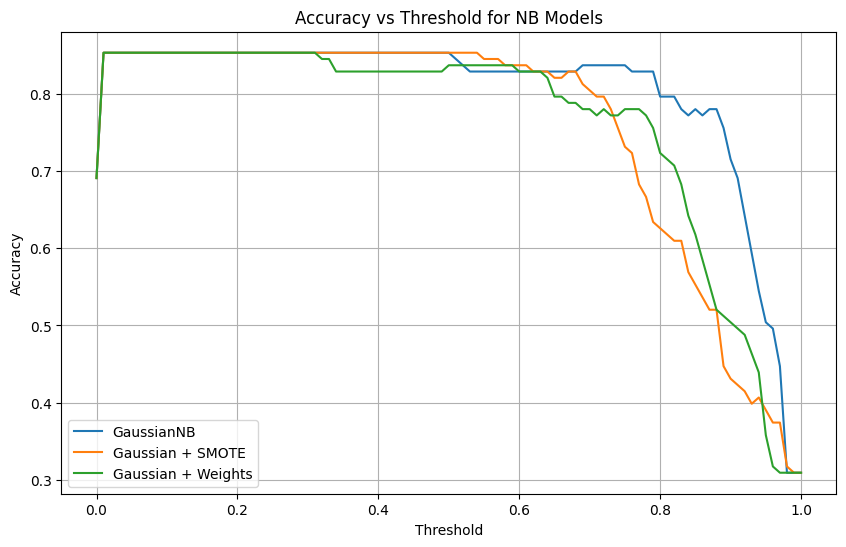

In [921]:


# Threshold curves for each model
models = {
    "GaussianNB": gnb,
    "Gaussian + SMOTE": gnb_sm,
    "Gaussian + Weights": gnb_w
}

plt.figure(figsize=(10,6))

for name, model in models.items():
    thr, acc = evaluate_thresholds(model, X_test, y_test)
    plt.plot(thr, acc, label=name)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold for NB Models")
plt.legend()
plt.grid(True)
plt.show()


**After evaluating multiple classifiers with different imbalance-handling strategies, the Decision Tree with balanced class weights demonstrated the best overall performance. It achieved higher recall for both classes, superior F1-scores, higher AUC, and greater interpretability compared to XGBoost. These properties make it the most suitable and reliable model for the loan approval prediction task, particularly due to the need to accurately identify high-risk (rejected) applicants while minimizing false rejections of qualified customers.**

In [922]:
joblib.dump(dt_weighted, "dt_weighted_model.pkl")
print("decision tree weighted model saved!")

decision tree weighted model saved!


In [923]:
new_df = pd.read_csv('/content/New Customer.csv')
pre = pd.read_csv('/content/preprocessed_data.csv')
print("New data loaded.")

New data loaded.


In [924]:

imputers = joblib.load("simple_imputers.pkl")
# Contains:
#   imputers["gender_mode"]
#   imputers["self_employed_mode"]
#   imputers["loan_term_mode"]
#   imputers["credit_history_mode"]

married_general_mode = joblib.load("married_general_mode.pkl")
dependents_group_mode = joblib.load("dependents_group_mode.pkl")
print("Loaded imputers successfully.")

loanamount_regressor = joblib.load("loanamount_regressor.pkl")
loanamount_ohe = joblib.load("loanamount_ohe.pkl")
print("Loaded LoanAmount regression model + encoder.")

scaler = joblib.load("scaler.pkl")
print("Loaded StandardScaler.")

training_columns = joblib.load("training_columns.pkl")
print("Loaded training column order.")

dt_weighted_model = joblib.load("dt_weighted_model.pkl")
print("Loaded decision tree weighted model.")

print("\n===== ALL PIPELINE COMPONENTS LOADED SUCCESSFULLY =====")


Loaded imputers successfully.
Loaded LoanAmount regression model + encoder.
Loaded StandardScaler.
Loaded training column order.
Loaded decision tree weighted model.

===== ALL PIPELINE COMPONENTS LOADED SUCCESSFULLY =====


In [925]:
# 1. Gender
new_df["Gender"] = new_df["Gender"].fillna(imputers["gender_mode"])

# 2. Married rule
new_df.loc[new_df["Married"].isnull() & (new_df["Education"]=="Graduate"), "Married"] = "Yes"
new_df.loc[new_df["Married"].isnull() & (new_df["Education"]=="Not Graduate"), "Married"] = "No"
new_df["Married"] = new_df["Married"].fillna(married_general_mode)

# 3. Dependents imputation by group
new_df["Dependents"] = new_df.apply(
    lambda row: dependents_group_mode[row["Married"]] if pd.isna(row["Dependents"]) else row["Dependents"],
    axis=1
)

# 4. Self-employed
new_df["Self_Employed"] = new_df["Self_Employed"].fillna(imputers["self_employed_mode"])

# 5. Loan term
new_df["Loan_Amount_Term"] = new_df["Loan_Amount_Term"].fillna(imputers["loan_term_mode"])

# 6. Credit history
new_df["Credit_History"] = new_df["Credit_History"].fillna(imputers["credit_history_mode"])


In [926]:
# Features used by the RF model (same as training)
rf_features = [
    'ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term',
    'Credit_History', 'Gender', 'Married', 'Dependents',
    'Education', 'Self_Employed', 'Property_Area'
]

missing = new_df["LoanAmount"].isnull()

if missing.any():

    # Select missing rows
    X_missing = new_df.loc[missing, rf_features]

    # Categorical columns RF encoder was trained on
    cat_cols = loanamount_ohe.feature_names_in_

    # One-hot transform
    X_cat = loanamount_ohe.transform(X_missing[cat_cols])

    # Numeric part
    X_num = X_missing.drop(columns=cat_cols).reset_index(drop=True)

    # Combine numeric + encoded categorical
    X_final = pd.concat([
        X_num,
        pd.DataFrame(X_cat, columns=loanamount_ohe.get_feature_names_out())
    ], axis=1)

    # Predict
    new_df.loc[missing, "LoanAmount"] = loanamount_regressor.predict(X_final)

print("Missing LoanAmount values predicted.")


Missing LoanAmount values predicted.


In [927]:
# Feature engineering
new_df["TotalIncome"] = new_df["ApplicantIncome"] + new_df["CoapplicantIncome"]

new_df["LoanAmount_log"] = np.log(new_df["LoanAmount"] + 1)
new_df["TotalIncome_log"] = np.log(new_df["TotalIncome"] + 1)

new_df["LoanAmount_log"] = np.log(new_df["LoanAmount"] + 1)
new_df["TotalIncome_log"] = np.log(new_df["TotalIncome"] + 1)

# Load original caps computed during training (in log space)
caps = joblib.load("log_caps.pkl")
loan_cap = caps["LoanAmount_log"]
income_cap = caps["TotalIncome_log"]

new_df["LoanAmount_log"] = np.clip(new_df["LoanAmount_log"], None, loan_cap)
new_df["TotalIncome_log"] = np.clip(new_df["TotalIncome_log"], None, income_cap)



In [928]:
new_df["Dependents"] = new_df["Dependents"].replace("3+", 3).astype(int)
new_df["Education"] = new_df["Education"].map({"Not Graduate":0, "Graduate":1})


In [929]:
nominal_cols = ['Gender','Married','Self_Employed','Property_Area']
new_df = pd.get_dummies(new_df, columns=nominal_cols, drop_first=True)


In [930]:
cols_to_scale = ['LoanAmount_log','TotalIncome_log','Loan_Amount_Term']
new_df[cols_to_scale] = scaler.transform(new_df[cols_to_scale])


In [931]:
print("PREPROCESSED NEW DATA ")
display(new_df)
print("\nShape:", new_df.shape)
print("\nColumns:", list(new_df.columns))

PREPROCESSED NEW DATA 


,Loan_ID,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001015,0,1,5720,0,110.0,0.273231,1.0,5720,-0.316879,-0.029490,True,True,False,False,True
1,LP001022,1,1,3076,1500,126.0,0.273231,1.0,4576,-0.045628,-0.445153,True,True,False,False,True
2,LP001031,2,1,5000,1800,208.0,0.273231,1.0,6800,0.957835,0.292693,True,True,False,False,True
3,LP001035,2,1,2340,2546,100.0,0.273231,1.0,4886,-0.507057,-0.323054,True,True,False,False,True
4,LP001051,0,0,3276,0,78.0,0.273231,1.0,3276,-1.001938,-1.067652,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,3,0,4009,1777,113.0,0.273231,1.0,5786,-0.263159,-0.008120,True,True,True,False,True
363,LP002975,0,1,4158,709,115.0,0.273231,1.0,4867,-0.228125,-0.330311,True,True,False,False,True
364,LP002980,0,1,3250,1993,126.0,0.273231,1.0,5243,-0.045628,-0.191692,True,False,False,True,False
365,LP002986,0,1,5000,2393,158.0,0.273231,1.0,7393,0.407040,0.448448,True,True,False,False,False



Shape: (367, 16)

Columns: ['Loan_ID', 'Dependents', 'Education', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'LoanAmount_log', 'TotalIncome_log', 'Gender_Male', 'Married_Yes', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [932]:

# Ensure new_df has same columns in same order
X_new = new_df.reindex(columns=training_columns, fill_value=0)

# Predict loan status
y_pred = dt_weighted_model.predict(X_new)


In [933]:
# Create a new dataframe with index and prediction only
result_df = pd.DataFrame({
    "loan id": new_df.index,
    "Loan_Status_Pred": y_pred
})
# Save to CSV
output_path = "loan_status_predictions.csv"
result_df.to_csv(output_path, index=False)

print(f"CSV saved successfully at: {output_path}")
display(result_df.head())


CSV saved successfully at: loan_status_predictions.csv


,loan id,Loan_Status_Pred
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


In [934]:
new_df["Loan_Status_Pred"] = y_pred
print("Predicted loan status column added to new_df.")
display(new_df.head())

Predicted loan status column added to new_df.


,Loan_ID,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Pred
0,LP001015,0,1,5720,0,110.0,0.273231,1.0,5720,-0.316879,-0.029490,True,True,False,False,True,1
1,LP001022,1,1,3076,1500,126.0,0.273231,1.0,4576,-0.045628,-0.445153,True,True,False,False,True,1
2,LP001031,2,1,5000,1800,208.0,0.273231,1.0,6800,0.957835,0.292693,True,True,False,False,True,1
3,LP001035,2,1,2340,2546,100.0,0.273231,1.0,4886,-0.507057,-0.323054,True,True,False,False,True,1
4,LP001051,0,0,3276,0,78.0,0.273231,1.0,3276,-1.001938,-1.067652,True,False,False,False,True,1


In [937]:
output_path = "full_loan_status_predictions.csv"
result_df.to_csv(output_path, index=False)

In [935]:
subset = new_df[(new_df["Married_Yes"] == True) & (new_df["Property_Area_Semiurban"] == True)]
total = len(subset)
approved = subset["Loan_Status_Pred"].sum()
percentage = (approved / total * 100) if total > 0 else 0
print(f"Total married semiurban customers: {total}")
print(f"Number approved: {approved}")
print(f"Approval %: {percentage:.2f}%")

Total married semiurban customers: 71
Number approved: 53
Approval %: 74.65%


/tmp/ipython-input-1124138610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Status_Pred", data=subset, palette="viridis")


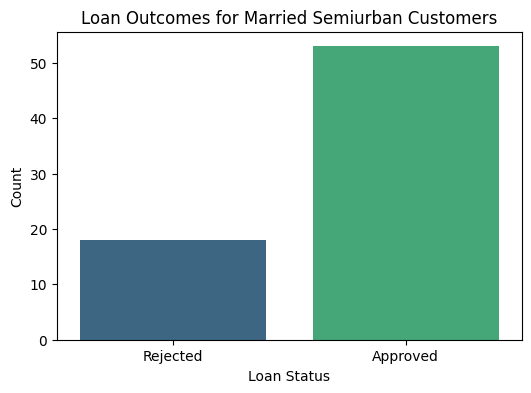

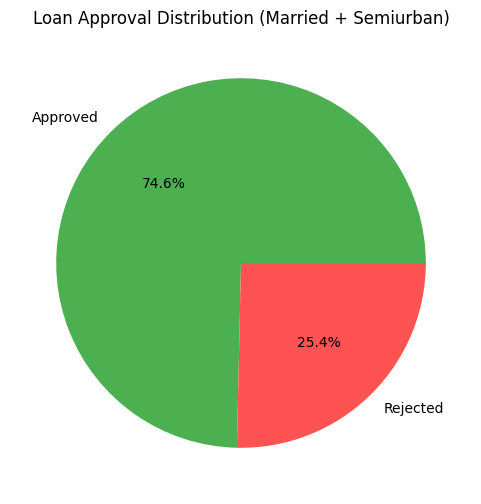

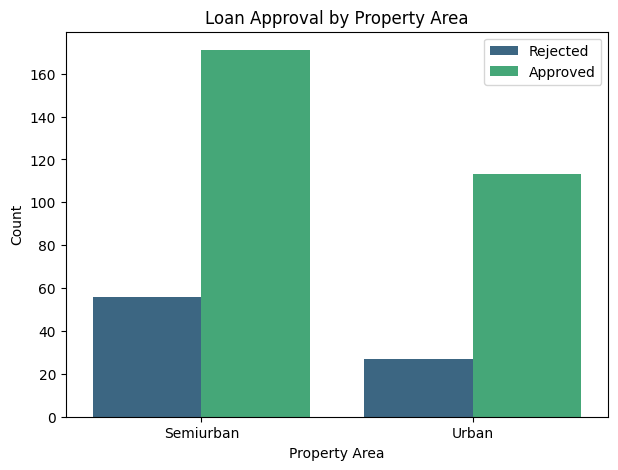

In [936]:
plt.figure(figsize=(6,4))
sns.countplot(x="Loan_Status_Pred", data=subset, palette="viridis")
plt.xticks([0,1], ["Rejected", "Approved"])
plt.title("Loan Outcomes for Married Semiurban Customers")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(6,6))
plt.pie(
    [approved, total - approved],
    labels=["Approved", "Rejected"],
    autopct="%1.1f%%",
    colors=["#4CAF50", "#FF5252"]
)
plt.title("Loan Approval Distribution (Married + Semiurban)")
plt.show()
plt.figure(figsize=(7,5))
sns.countplot(x="Property_Area_Urban", hue="Loan_Status_Pred", data=new_df, palette="viridis")
plt.xticks([0,1], ["Semiurban", "Urban"])
plt.title("Loan Approval by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.legend(["Rejected", "Approved"])
plt.show()